
Building 'Normal' Baseline...
Processing 0D.csv...
Processing 1D.csv...

Training Isolation Forest on Tolerable Data (0D, 1D)...

Processing Evaluation Datasets...
Processing 0E.csv...
Processing 1E.csv...
Processing 2E.csv...
Processing 3E.csv...
Processing 4E.csv...

Generating and Smoothing Anomaly Scores...


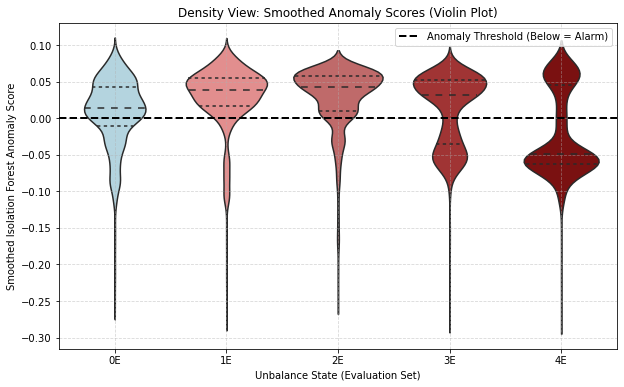

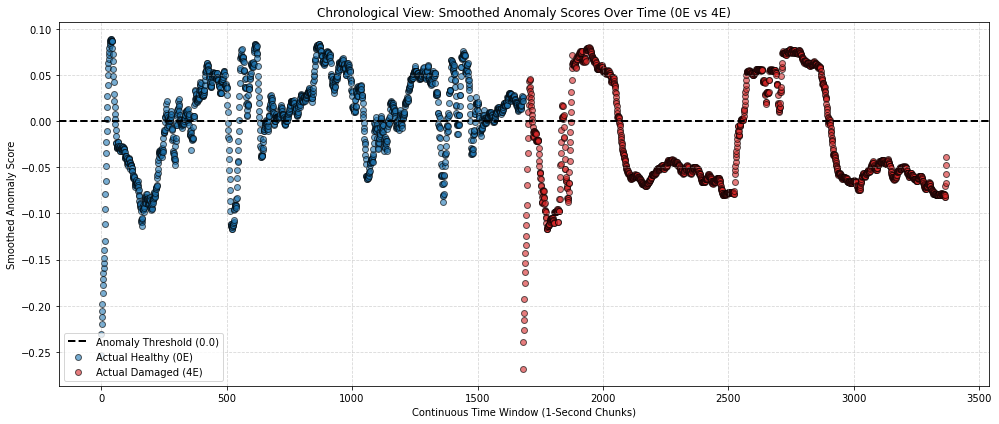

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # NEW: Added for beautiful Violin Plots
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis, skew
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Advanced Feature Extraction (Order Analysis)
# ==========================================
def extract_features(vibration_window, rpm_window, fs=4096):
    """Extracts features, normalizing frequency to running speed (Orders)."""
    
    # Operating Condition
    avg_rpm = np.mean(rpm_window)
    run_speed_hz = avg_rpm / 60.0
    if run_speed_hz == 0: run_speed_hz = 1e-5 
        
    # Time-Domain & Statistical Features
    rms = np.sqrt(np.mean(vibration_window**2))
    peak_to_peak = np.ptp(vibration_window)
    kurt = kurtosis(vibration_window, fisher=False) 
    skewness = skew(vibration_window)
    
    # Frequency-Domain Features (FFT)
    N = len(vibration_window)
    yf = fft(vibration_window)
    xf = fftfreq(N, 1 / fs)[:N//2]
    magnitude = 2.0/N * np.abs(yf[0:N//2])
    dominant_freq = xf[np.argmax(magnitude)]
    
    # ORDER ANALYSIS
    dominant_order = dominant_freq / run_speed_hz
    
    return [rms, peak_to_peak, kurt, skewness, dominant_order]

def process_file_to_features(file_path, label, fs=4096):
    print(f"Processing {file_path.name}...")
    df = pd.read_csv(file_path)
    
    signal = df['Vibration_1'].values
    rpm_signal = df['Measured_RPM'].values 
    
    num_chunks = len(signal) // fs
    features_list = []
    
    for i in range(num_chunks):
        start_idx = i * fs
        end_idx = start_idx + fs
        
        window_vib = signal[start_idx:end_idx]
        window_rpm = rpm_signal[start_idx:end_idx]
        
        features = extract_features(window_vib, window_rpm, fs)
        features.append(label)
        features_list.append(features)
        
    cols = ['RMS', 'Peak_to_Peak', 'Kurtosis', 'Skewness', 'Dominant_Order', 'State']
    return pd.DataFrame(features_list, columns=cols)

# ==========================================
# 2. Train on Tolerable Baseline (0D and 1D)
# ==========================================
data_dir = Path(r"D:\vibration_dataset")

tolerable_states = ['0D', '1D']
train_dataframes = []

print("\nBuilding 'Normal' Baseline...")
for state in tolerable_states:
    file_path = data_dir / f"{state}.csv"
    if file_path.exists():
        df_temp = process_file_to_features(file_path, label=f"{state}_Train")
        train_dataframes.append(df_temp)
    else:
        print(f"Error: Could not find {file_path.name} for training.")

df_train = pd.concat(train_dataframes, ignore_index=True)

feature_cols = ['RMS', 'Peak_to_Peak', 'Kurtosis', 'Skewness', 'Dominant_Order']
X_train = df_train[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"\nTraining Isolation Forest on Tolerable Data ({', '.join(tolerable_states)})...")
# Strict 15% contamination
model = IsolationForest(n_estimators=200, contamination=0.15, random_state=42)
model.fit(X_train_scaled)

# ==========================================
# 3. Evaluate on Unseen Data (0E through 4E)
# ==========================================
eval_states = ['0E', '1E', '2E', '3E', '4E']
eval_dataframes = []

print("\nProcessing Evaluation Datasets...")
for state in eval_states:
    file_path = data_dir / f"{state}.csv"
    if file_path.exists():
        df_temp = process_file_to_features(file_path, label=state)
        eval_dataframes.append(df_temp)
    else:
        print(f"Warning: {file_path.name} not found.")

df_eval = pd.concat(eval_dataframes, ignore_index=True)
X_eval = df_eval[feature_cols]

X_eval_scaled = scaler.transform(X_eval)

# ==========================================
# 4. Predict and Apply Rolling Average (Smoothing)
# ==========================================
print("\nGenerating and Smoothing Anomaly Scores...")
df_eval['Raw_Anomaly_Score'] = model.decision_function(X_eval_scaled)

# 15-second rolling average
window_size = 15
df_eval['Smoothed_Score'] = df_eval.groupby('State')['Raw_Anomaly_Score'].transform(
    lambda x: x.rolling(window=window_size, min_periods=1).mean()
)

# ==========================================
# 5. Visualization 1: The Violin Plot (Replaces Boxplot)
# ==========================================
plt.figure(figsize=(10, 6))

# Custom color palette matching our previous progression
colors = ['lightblue', 'lightcoral', 'indianred', 'firebrick', 'darkred']

# Seaborn handles the density mapping automatically
sns.violinplot(
    data=df_eval, 
    x='State', 
    y='Smoothed_Score', 
    order=eval_states, 
    palette=colors, 
    inner="quartile" # Shows median and quartiles inside the violin
)

plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Anomaly Threshold (Below = Alarm)')

plt.title('Density View: Smoothed Anomaly Scores (Violin Plot)')
plt.xlabel('Unbalance State (Evaluation Set)')
plt.ylabel('Smoothed Isolation Forest Anomaly Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# ==========================================
# 6. Visualization 2: Chronological Scatter Plot
# ==========================================
df_scatter = df_eval[df_eval['State'].isin(['0E', '4E'])].copy()
df_scatter.reset_index(drop=True, inplace=True)

plt.figure(figsize=(14, 6))

healthy_mask = df_scatter['State'] == '0E'
plt.scatter(df_scatter[healthy_mask].index, 
            df_scatter[healthy_mask]['Smoothed_Score'], 
            c='tab:blue', alpha=0.6, edgecolors='k', label='Actual Healthy (0E)')

damaged_mask = df_scatter['State'] == '4E'
plt.scatter(df_scatter[damaged_mask].index, 
            df_scatter[damaged_mask]['Smoothed_Score'], 
            c='tab:red', alpha=0.6, edgecolors='k', label='Actual Damaged (4E)')

plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Anomaly Threshold (0.0)')

plt.title('Chronological View: Smoothed Anomaly Scores Over Time (0E vs 4E)')
plt.xlabel('Continuous Time Window (1-Second Chunks)')
plt.ylabel('Smoothed Anomaly Score')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Hunting for exactly 1500 RPM in all datasets...
State 0D: True Median 1X Peak = 0.002119 g
State 1D: True Median 1X Peak = 0.005678 g
State 2D: True Median 1X Peak = 0.003268 g
State 3D: True Median 1X Peak = 0.005709 g
State 4D: True Median 1X Peak = 0.013407 g


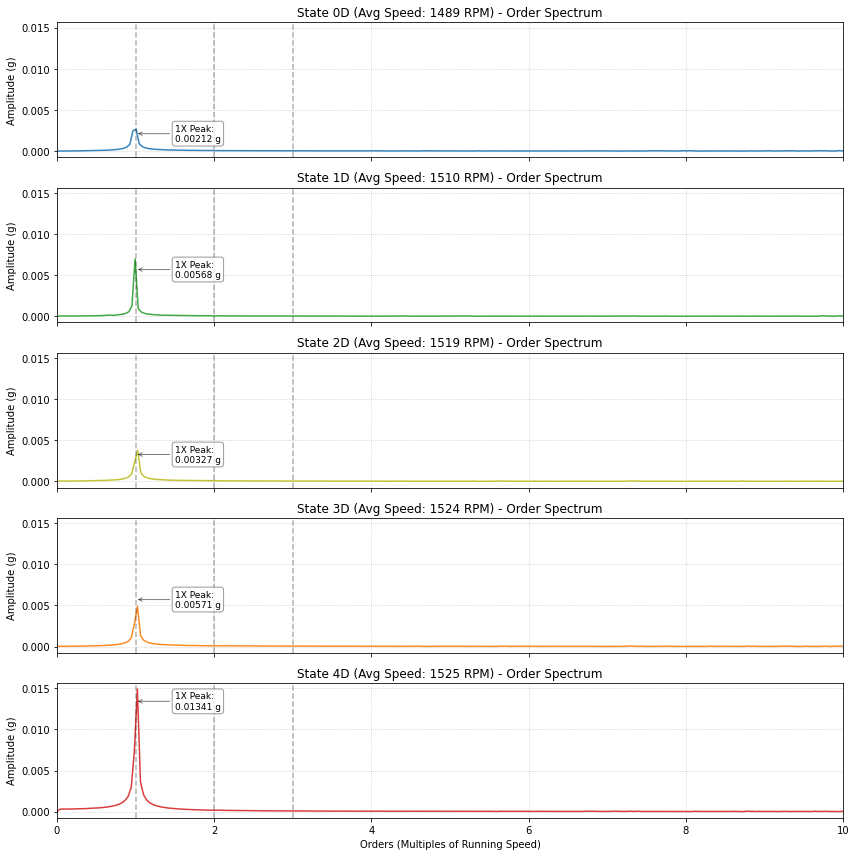

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from pathlib import Path

# ==========================================
# 1. Setup
# ==========================================
data_dir = Path(r"D:\vibration_dataset")
fs = 4096  # Sampling rate
states = ['0D', '1D', '2D', '3D', '4D']

# Create a figure with 5 stacked subplots, locking the Y-axis so heights are relative
fig, axes = plt.subplots(len(states), 1, figsize=(12, 12), sharex=True, sharey=True)

# Custom colors for the progression of severity
colors = ['tab:blue', 'tab:green', 'tab:olive', 'tab:orange', 'tab:red']

print("Hunting for exactly 1500 RPM in all datasets...")

# ==========================================
# 2. Process and Plot Each Dataset
# ==========================================
TARGET_RPM = 1500

for i, (state, ax) in enumerate(zip(states, axes)):
    file_path = data_dir / f"{state}.csv"
    
    if not file_path.exists():
        ax.text(0.5, 0.5, f"{state}.csv not found", ha='center')
        continue
        
    df = pd.read_csv(file_path)
    
    # --- THE FIX: Order Tracking (Averaging over a speed range) ---
    # A single 1-second snapshot is vulnerable to transient acceleration noise.
    # We find ALL windows where the motor is between 1400 and 1600 RPM and take the median 1X peak.
    valid_data = df[(df['Measured_RPM'] >= 1400) & (df['Measured_RPM'] <= 1600)]
    
    if len(valid_data) >= fs:
        num_chunks = len(valid_data) // fs
        peaks_1x = []
        for chunk in range(num_chunks):
            c_start = chunk * fs
            c_end = c_start + fs
            vib_chunk = valid_data['Vibration_1'].iloc[c_start:c_end].values
            vib_chunk = vib_chunk - np.mean(vib_chunk)
            rpm_chunk = valid_data['Measured_RPM'].iloc[c_start:c_end].mean()
            
            N_c = len(vib_chunk)
            y_freq_c = fft(vib_chunk)
            mag_c = 2.0/N_c * np.abs(y_freq_c[0:N_c//2])
            x_orders_c = fftfreq(N_c, 1 / fs)[:N_c//2] / (rpm_chunk / 60.0)
            
            mask = (x_orders_c >= 0.9) & (x_orders_c <= 1.1)
            if any(mask):
                peaks_1x.append(np.max(mag_c[mask]))
        peak_1x_mag = np.median(peaks_1x)
    else:
        peak_1x_mag = 0.0 # Fallback
        
    peak_1x_order = 1.0 # Centered perfectly at 1.0 for chart annotation
    
    # 1. Find the single closest moment to TARGET_RPM for the visual plot
    diff = (df['Measured_RPM'] - TARGET_RPM).abs()
    center_idx = diff.idxmin()
    
    # Safely extract a 1-second window centered around that exact moment
    start_idx = center_idx - (fs // 2)
    if start_idx < 0: start_idx = 0
    elif start_idx + fs > len(df): start_idx = len(df) - fs
        
    # 2. Extract 1-second window and remove DC offset
    vib_signal = df['Vibration_1'].iloc[start_idx : start_idx + fs].values
    vib_signal = vib_signal - np.mean(vib_signal)
    
    avg_rpm = df['Measured_RPM'].iloc[start_idx : start_idx + fs].mean()
    run_speed_hz = avg_rpm / 60.0
    
    # 3. Perform FFT
    N = len(vib_signal)
    y_freq = fft(vib_signal)
    x_freq = fftfreq(N, 1 / fs)[:N//2]
    magnitude = 2.0/N * np.abs(y_freq[0:N//2])
    
    # 4. CONVERT TO ORDERS
    x_orders = x_freq / run_speed_hz
    
    # Print the true median description to the console
    print(f"State {state}: True Median 1X Peak = {peak_1x_mag:.6f} g")
    
    # 5. Plotting
    ax.plot(x_orders, magnitude, color=colors[i], alpha=0.9)
    
    # Add visual markers for 1X, 2X, and 3X Orders
    for order in [1, 2, 3]:
        ax.axvline(order, color='black', linestyle='--', alpha=0.3)
        
    # --- NEW: Annotate the chart with the exact value ---
    ax.annotate(f'1X Peak:\n{peak_1x_mag:.5f} g', 
                xy=(peak_1x_order, peak_1x_mag), 
                xytext=(1.5, peak_1x_mag if peak_1x_mag > 0.0001 else 0.0002), 
                arrowprops=dict(facecolor='black', arrowstyle='->', alpha=0.5),
                fontsize=9, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
        
    ax.set_title(f"State {state} (Avg Speed: {avg_rpm:.0f} RPM) - Order Spectrum")
    ax.set_ylabel('Amplitude (g)')
    ax.grid(True, linestyle=':', alpha=0.7)

# Focus strictly on the first 10 Orders
plt.xlim(0, 10)
plt.xlabel('Orders (Multiples of Running Speed)')
plt.tight_layout()
plt.show()